# Phase 10 — Feature ↔ Target Relationship Analysis
**Topic:** Predicting Road Traffic Collision Severity and Identifying High-Risk Locations and Times
**Dataset:** UK DfT STATS19 Road Safety Data (model-ready training partition)
**Inputs:** `cleaned_data/X_train_model_ready.csv` + `cleaned_data/y_train_classification.csv`

---
### Objective
Measure which features are related to `collision_severity` (1 = Fatal, 2 = Serious, 3 = Slight) before building classifiers.

### Approach
| Feature type | Test | Effect size (how strong) |
|---|---|---|
| Discrete (binary dummies, flags) | Chi-square test of independence | Cramér's V |
| Continuous (scaled numeric) | Kruskal-Wallis H test | Epsilon² and Spearman ρ |
| All features | — | Mutual information (captures non-linear relationships) |

Plus a practical view: the **severe rate** (Fatal + Serious %) for each feature value.

> Only the **training** partition is used, so nothing here leaks information from the test set.

## 1. Load and combine X_train + y_train

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import chi2_contingency, kruskal, spearmanr
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

data_path = Path("../../cleaned_data")
if not data_path.exists():
    data_path = Path("cleaned_data")

X = pd.read_csv(data_path / "X_train_model_ready.csv")
y = pd.read_csv(data_path / "y_train_classification.csv")["collision_severity"]

assert len(X) == len(y), f"Row mismatch: X={len(X):,}, y={len(y):,}"

TARGET = "collision_severity"
SEVERITY_LABELS = {1: "Fatal", 2: "Serious", 3: "Slight"}

df = pd.concat([X, y], axis=1)
df["is_severe"] = (df[TARGET] <= 2).astype(int)  # Fatal or Serious

print(f"X_train  : {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"y_train  : {y.shape[0]:,} rows")
print(f"Combined : {df.shape[0]:,} rows x {df.shape[1]} cols")
df.head(10)

X_train  : 411,040 rows x 66 features
y_train  : 411,040 rows
Combined : 411,040 rows x 68 cols


,speed_limit,number_of_vehicles,hour_of_day,latitude,longitude,min_driver_age,max_driver_age,avg_driver_age,vehicle_type_diversity,month,road_type_1,road_type_2,road_type_3,road_type_6,road_type_7,road_type_9,urban_or_rural_area_-1,urban_or_rural_area_1,urban_or_rural_area_2,urban_or_rural_area_3,time_of_day_bucket_Evening,time_of_day_bucket_Evening Rush,time_of_day_bucket_Midday,time_of_day_bucket_Morning Rush,time_of_day_bucket_Night,season_Autumn,season_Spring,season_Summer,season_Winter,weather_conditions_1.0,weather_conditions_2.0,weather_conditions_3.0,weather_conditions_4.0,weather_conditions_5.0,weather_conditions_6.0,weather_conditions_7.0,weather_conditions_8.0,weather_conditions_9.0,light_conditions_1.0,light_conditions_4.0,light_conditions_5.0,light_conditions_6.0,light_conditions_7.0,road_surface_conditions_1.0,road_surface_conditions_2.0,road_surface_conditions_3.0,road_surface_conditions_4.0,road_surface_conditions_5.0,road_surface_conditions_9.0,junction_detail_0.0,junction_detail_13.0,junction_detail_16.0,junction_detail_17.0,junction_detail_18.0,junction_detail_19.0,junction_detail_99.0,trunk_road_flag,has_bus_or_coach,has_car,has_hgv,has_motorcycle,has_other,has_pedal_cycle,has_undocumented_code_33,has_van_or_goods_light,is_weekend,collision_severity,is_severe
0,-1.106472,0.256656,0.826077,-0.679527,0.808239,-0.226047,-0.858234,-0.626218,1.201491,-1.377281,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2,0,1,0,1,0,0,0,0,0,3,0
1,2.370443,-1.199041,0.244020,-0.418773,-2.426762,1.803985,0.938841,1.500941,-0.790148,0.687450,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-1,0,1,0,0,0,0,0,0,0,3,0
2,-0.411089,-1.199041,0.632058,0.789204,-0.225375,0.044624,-0.618624,-0.342597,-0.790148,0.392488,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2,0,0,0,0,0,1,0,0,0,1,1
3,1.675060,1.712352,-0.726074,0.060308,-0.361431,-0.226047,0.040303,-0.224421,1.201491,0.982411,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,1,0,0,0,0,0,0,3,0
4,-1.106472,-1.199041,1.408134,-0.596774,0.700275,1.465647,0.639329,1.146415,-0.790148,1.277373,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2,0,1,0,0,0,0,0,0,1,3,0
5,-1.106472,0.256656,0.438039,-0.546692,-2.040888,0.044624,-0.438917,-0.236239,-0.790148,0.982411,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1,0,1,0,0,0,0,0,0,0,3,0
6,-0.411089,0.256656,-2.666263,-0.390221,1.789250,-0.970392,-1.337454,-1.299818,-0.790148,0.392488,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2,0,1,0,0,0,0,0,0,0,2,1
7,-0.411089,0.256656,-2.472244,0.089221,-0.431927,-0.835056,-0.139404,-0.519860,-0.790148,0.982411,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2,0,1,0,0,0,0,0,0,1,3,0
8,-0.411089,-1.199041,0.438039,0.749524,-0.871207,0.585966,-0.139404,0.224646,-0.790148,-1.082320,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,

In [2]:
# Chart style: recessive axes, light grid, single-hue bars
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e6e5e0", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK2,
    "axes.titlecolor": INK,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "xtick.color": INK2,
    "ytick.color": INK2,
    "font.size": 10,
})

## 2. Target distribution

,label,count,percent
collision_severity,,,
1,Fatal,6042,1.47
2,Serious,93450,22.74
3,Slight,311548,75.80


Overall severe rate (Fatal + Serious): 24.20%


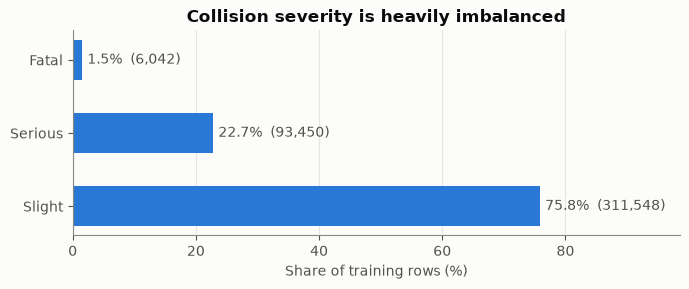

In [3]:
target_dist = pd.DataFrame({
    "label": [SEVERITY_LABELS[k] for k in sorted(y.unique())],
    "count": y.value_counts().sort_index().values,
    "percent": (y.value_counts(normalize=True).sort_index() * 100).round(2).values,
}, index=sorted(y.unique()))
target_dist.index.name = TARGET
display(target_dist)

overall_severe = df["is_severe"].mean() * 100
print(f"Overall severe rate (Fatal + Serious): {overall_severe:.2f}%")

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(target_dist["label"], target_dist["percent"], color=BLUE, height=0.55)
ax.bar_label(bars, labels=[f"{p:.1f}%  ({c:,})" for p, c in zip(target_dist["percent"], target_dist["count"])],
             padding=4, color=INK2)
ax.invert_yaxis()
ax.set_xlabel("Share of training rows (%)")
ax.set_title("Collision severity is heavily imbalanced")
ax.set_xlim(0, target_dist["percent"].max() * 1.3)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 3. Split features into discrete and continuous
Features with ≤ 10 distinct values (one-hot dummies, `has_*` flags, `is_weekend`, `trunk_road_flag`) are treated as **discrete**; the standardized numeric features are **continuous**.

In [4]:
features = list(X.columns)
discrete = [c for c in features if X[c].nunique() <= 10]
continuous = [c for c in features if c not in discrete]
constant = [c for c in features if X[c].nunique() <= 1]

print(f"Discrete features   : {len(discrete)}")
print(f"Continuous features : {len(continuous)} -> {continuous}")
print(f"Constant features   : {constant or 'none'}")

Discrete features   : 58
Continuous features : 8 -> ['number_of_vehicles', 'hour_of_day', 'latitude', 'longitude', 'min_driver_age', 'max_driver_age', 'avg_driver_age', 'month']
Constant features   : none


## 4. Discrete features — Chi-square test + Cramér's V
- **Chi-square p-value** answers *"is there any relationship?"* With ~400k rows almost everything is significant, so the p-value alone is not useful.
- **Cramér's V** (0 → 1) answers *"how strong is it?"* Strength labels follow Cohen's guideline, adjusted for degrees of freedom (df\* = min(rows, cols) − 1). For a binary feature (df\* = 1): < 0.10 negligible, 0.10–0.30 weak, 0.30–0.50 moderate, > 0.50 strong. Thresholds shrink by √df\* for features with more categories.

In [5]:
def cramers_v(table):
    chi2, p, dof, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    r, k = table.shape
    return chi2, p, dof, np.sqrt(chi2 / (n * (min(r, k) - 1)))


def v_strength(v, df_star):
    small, medium, large = (t / np.sqrt(df_star) for t in (0.10, 0.30, 0.50))
    if v < small:
        return "negligible"
    if v < medium:
        return "weak"
    if v < large:
        return "moderate"
    return "strong"


chi_rows = []
for c in discrete:
    table = pd.crosstab(df[c], df[TARGET])
    if table.shape[0] < 2:
        continue
    chi2, p, dof, v = cramers_v(table)
    df_star = min(table.shape) - 1
    chi_rows.append({"feature": c, "chi2": chi2, "dof": dof, "p_value": p, "cramers_v": v,
                     "strength": v_strength(v, df_star)})

chi_df = pd.DataFrame(chi_rows).sort_values("cramers_v", ascending=False).reset_index(drop=True)
chi_df.round({"chi2": 1, "cramers_v": 4}).style.format({"p_value": "{:.2e}"})

,feature,chi2,dof,p_value,cramers_v,strength
0,has_car,4514.800000,2,0.00e+00,0.104800,weak
1,urban_or_rural_area_2,4483.200000,2,0.00e+00,0.104400,weak
2,urban_or_rural_area_1,4482.500000,2,0.00e+00,0.104400,weak
3,has_motorcycle,4021.000000,2,0.00e+00,0.098900,negligible
4,speed_limit,6804.900000,10,0.00e+00,0.091000,weak
5,light_conditions_6.0,2749.400000,2,0.00e+00,0.081800,negligible
6,road_type_6,1775.800000,2,0.00e+00,0.065700,negligible
7,trunk_road_flag,3458.900000,4,0.00e+00,0.064900,negligible
8,road_type_9,1399.600000,2,1.21e-304,0.058400,negligible
9,has_hgv,1390.200000,2,1.31e-302,0.058200,negligible


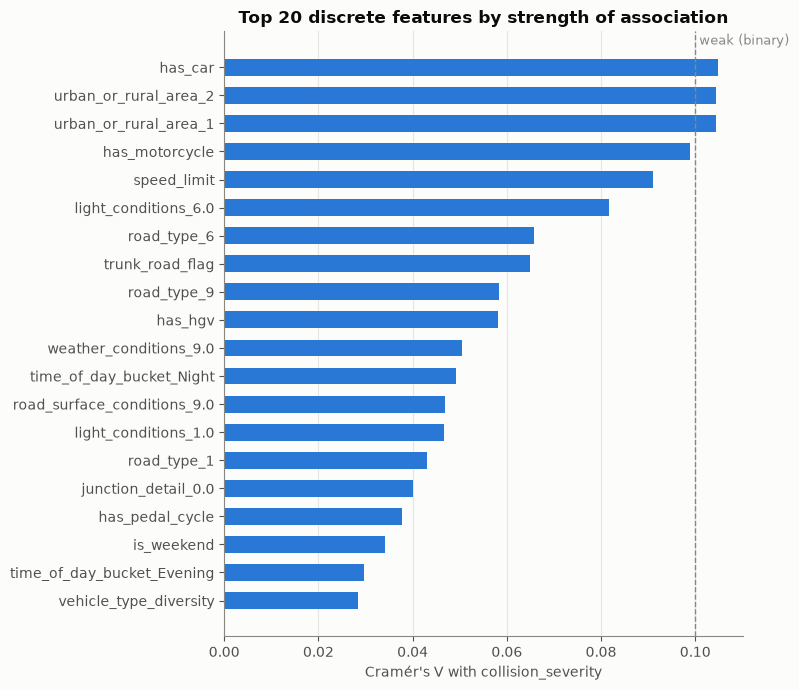

In [6]:
top = chi_df.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top["feature"], top["cramers_v"], color=BLUE, height=0.6)
ax.axvline(0.10, color=MUTED, linestyle="--", linewidth=1)
ax.text(0.10, len(top) - 0.3, " weak (binary)", color=MUTED, fontsize=9, va="bottom")
ax.set_xlabel("Cramér's V with collision_severity")
ax.set_title("Top 20 discrete features by strength of association")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### 4b. Grouped view — original categorical variables
One-hot encoding splits one variable (e.g. `light_conditions`) into many dummies, which spreads its association thin. Rebuilding each original variable from its dummies gives a fairer, variable-level comparison.

In [7]:
prefixes = ["road_type", "urban_or_rural_area", "time_of_day_bucket", "season",
            "weather_conditions", "light_conditions", "road_surface_conditions", "junction_detail"]

group_rows = []
for prefix in prefixes:
    cols = [c for c in features if c.startswith(prefix + "_")]
    if len(cols) < 2:
        continue
    category = df[cols].idxmax(axis=1).str.replace(prefix + "_", "", regex=False)
    table = pd.crosstab(category, df[TARGET])
    chi2, p, dof, v = cramers_v(table)
    group_rows.append({"variable": prefix, "n_categories": len(cols), "chi2": chi2,
                       "p_value": p, "cramers_v": v,
                       "strength": v_strength(v, min(table.shape) - 1)})

group_df = pd.DataFrame(group_rows).sort_values("cramers_v", ascending=False).reset_index(drop=True)
group_df.round({"chi2": 1, "cramers_v": 4}).style.format({"p_value": "{:.2e}"})

,variable,n_categories,chi2,p_value,cramers_v,strength
0,urban_or_rural_area,4,4485.800000,0.00e+00,0.073900,weak
1,road_type,6,3179.000000,0.00e+00,0.062200,negligible
2,light_conditions,5,3020.100000,0.00e+00,0.060600,negligible
3,time_of_day_bucket,5,1620.900000,0.00e+00,0.044400,negligible
4,weather_conditions,9,1378.400000,7.27e-284,0.040900,negligible
5,road_surface_conditions,6,1016.000000,6.80e-212,0.035200,negligible
6,junction_detail,7,918.900000,4.89e-189,0.033400,negligible
7,season,4,149.500000,9.92e-30,0.013500,negligible


## 5. Continuous features — Kruskal-Wallis + Spearman
- **Kruskal-Wallis H** tests whether the feature's distribution differs across the three severity classes (no normality assumption).
- **Epsilon²** is its effect size: < 0.01 negligible, 0.01–0.04 weak, 0.04–0.16 moderate, > 0.16 strong.
- **Spearman ρ** uses a severity score (1 = Slight, 2 = Serious, 3 = Fatal), so **positive ρ means higher values go with more severe collisions**.
- Class means are in **standardized units** (z-scores), because these columns were scaled in notebook 12.

In [8]:
severity_score = 4 - df[TARGET]  # 1 = Slight, 2 = Serious, 3 = Fatal
n, k = len(df), df[TARGET].nunique()

cont_rows = []
for c in continuous:
    groups = [df.loc[df[TARGET] == cls, c] for cls in (1, 2, 3)]
    H, p = kruskal(*groups)
    rho, _ = spearmanr(df[c], severity_score)
    cont_rows.append({
        "feature": c,
        "kruskal_H": H,
        "p_value": p,
        "epsilon_sq": (H - k + 1) / (n - k),
        "spearman_rho": rho,
        "mean_Fatal": groups[0].mean(),
        "mean_Serious": groups[1].mean(),
        "mean_Slight": groups[2].mean(),
    })

cont_df = pd.DataFrame(cont_rows).sort_values("epsilon_sq", ascending=False).reset_index(drop=True)
cont_df["strength"] = pd.cut(cont_df["epsilon_sq"], [-np.inf, 0.01, 0.04, 0.16, np.inf],
                             labels=["negligible", "weak", "moderate", "strong"])
cont_df.round(4).style.format({"p_value": "{:.2e}"})

,feature,kruskal_H,p_value,epsilon_sq,spearman_rho,mean_Fatal,mean_Serious,mean_Slight,strength
0,number_of_vehicles,3606.060600,0.00e+00,0.008800,-0.093600,-0.078200,-0.122000,0.038100,negligible
1,latitude,2722.141100,0.00e+00,0.006600,0.080400,0.336700,0.167100,-0.056700,negligible
2,longitude,2059.039900,0.00e+00,0.005000,-0.068800,-0.297800,-0.112000,0.039400,negligible
3,max_driver_age,870.941100,0.00e+00,0.002100,0.043600,0.243700,0.069300,-0.025500,negligible
4,avg_driver_age,854.173700,0.00e+00,0.002100,0.043100,0.253600,0.075600,-0.027600,negligible
5,min_driver_age,376.327100,0.00e+00,0.000900,0.027600,0.217400,0.066700,-0.024200,negligible
6,hour_of_day,44.393400,0.00e+00,0.000100,0.009400,-0.066500,0.009200,-0.001500,negligible
7,month,14.358400,8.00e-04,0.000000,0.005500,0.029000,0.009000,-0.003300,negligible


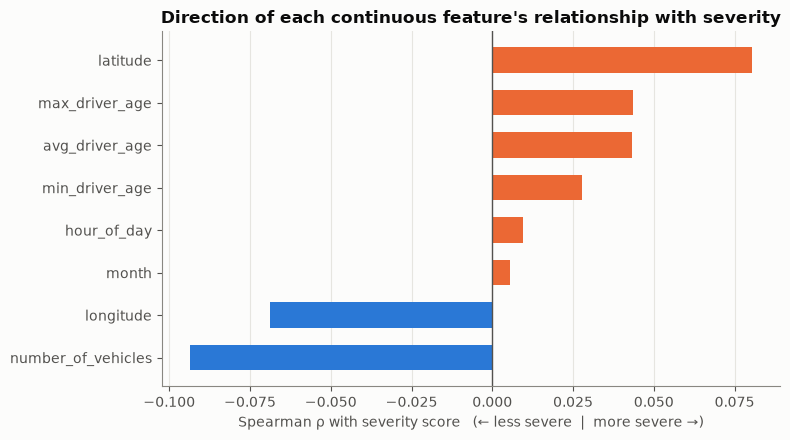

In [9]:
plot_df = cont_df.sort_values("spearman_rho")
colors = [ORANGE if r > 0 else BLUE for r in plot_df["spearman_rho"]]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot_df["feature"], plot_df["spearman_rho"], color=colors, height=0.6)
ax.axvline(0, color=INK2, linewidth=1)
ax.set_xlabel("Spearman ρ with severity score   (← less severe  |  more severe →)")
ax.set_title("Direction of each continuous feature's relationship with severity")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### 5b. Severe rate across the range of each continuous feature
Each feature is cut into up to 10 equal-sized bins (deciles); features with 20 or fewer distinct values use each value as its own bin (values with < 500 rows are skipped). A flat line means no relationship; a slope or curve shows where risk changes, including non-linear patterns that Spearman ρ can miss.

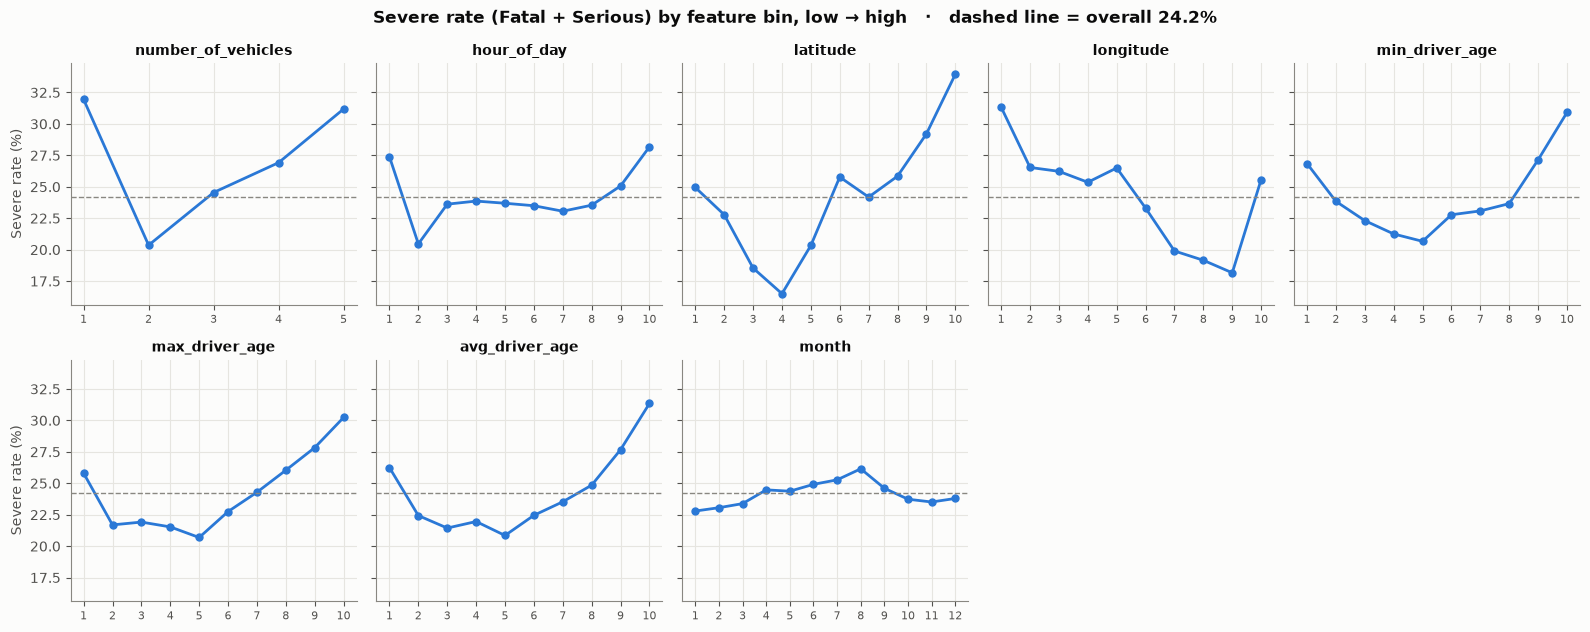

In [10]:
ncols = 5
nrows = int(np.ceil(len(continuous) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows), sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, c in zip(axes, continuous):
    if df[c].nunique() <= 20:
        counts = df[c].value_counts()
        bins = df[c].where(df[c].isin(counts[counts >= 500].index))
    else:
        bins = pd.qcut(df[c], q=10, duplicates="drop")
    rate = df.groupby(bins, observed=True)["is_severe"].mean().sort_index() * 100
    ax.plot(range(1, len(rate) + 1), rate.values, color=BLUE, linewidth=2, marker="o", markersize=5)
    ax.axhline(overall_severe, color=MUTED, linestyle="--", linewidth=1)
    ax.set_title(c, fontsize=10)
    ax.set_xticks(range(1, len(rate) + 1))
    ax.tick_params(axis="x", labelsize=8)

for ax in axes[len(continuous):]:
    ax.set_visible(False)

for ax in axes[::ncols]:
    ax.set_ylabel("Severe rate (%)")

fig.suptitle(f"Severe rate (Fatal + Serious) by feature bin, low → high   ·   dashed line = overall {overall_severe:.1f}%",
             fontsize=12, fontweight="bold", color=INK)
plt.tight_layout()
plt.show()

## 6. Binary features — severe rate when the feature is present
**Lift** = severe rate when the feature = 1 ÷ overall severe rate. Lift > 1 means the condition is linked to more severe outcomes; lift < 1 means less severe. Features present in fewer than 0.5% of rows are dropped because their rates are unreliable.

In [11]:
binary = [c for c in discrete if set(X[c].dropna().unique()) <= {0, 1}]
min_support = 0.005

bin_rows = []
for c in binary:
    present = df[c] == 1
    support = present.mean()
    if support < min_support or support > 1 - min_support:
        continue
    rate_1 = df.loc[present, "is_severe"].mean() * 100
    rate_0 = df.loc[~present, "is_severe"].mean() * 100
    fatal_1 = (df.loc[present, TARGET] == 1).mean() * 100
    bin_rows.append({
        "feature": c,
        "rows_with_1": int(present.sum()),
        "support_%": support * 100,
        "severe_%_when_1": rate_1,
        "severe_%_when_0": rate_0,
        "fatal_%_when_1": fatal_1,
        "lift": rate_1 / overall_severe,
    })

bin_df = pd.DataFrame(bin_rows)
bin_df["abs_diff"] = (bin_df["severe_%_when_1"] - bin_df["severe_%_when_0"]).abs()
bin_df = bin_df.sort_values("lift", ascending=False).reset_index(drop=True)
bin_df.drop(columns="abs_diff").round(2)

,feature,rows_with_1,support_%,severe_%_when_1,severe_%_when_0,fatal_%_when_1,lift
0,light_conditions_6.0,21973,5.35,34.94,23.60,4.89,1.44
1,has_motorcycle,67994,16.54,33.72,22.32,2.05,1.39
2,has_undocumented_code_33,5516,1.34,30.82,24.11,0.56,1.27
3,time_of_day_bucket_Night,23466,5.71,30.56,23.82,3.43,1.26
4,has_other,8138,1.98,30.38,24.08,2.96,1.25
5,weather_conditions_4.0,3607,0.88,29.94,24.15,2.63,1.24
6,urban_or_rural_area_2,134858,32.81,29.34,21.70,2.83,1.21
7,light_conditions_5.0,2957,0.72,29.08,24.17,2.47,1.20
8,weather_conditions_5.0,4130,1.00,27.12,24.18,2.35,1.12
9,has_hgv,16044,3.90,26.84,24.10,4.94,1.11


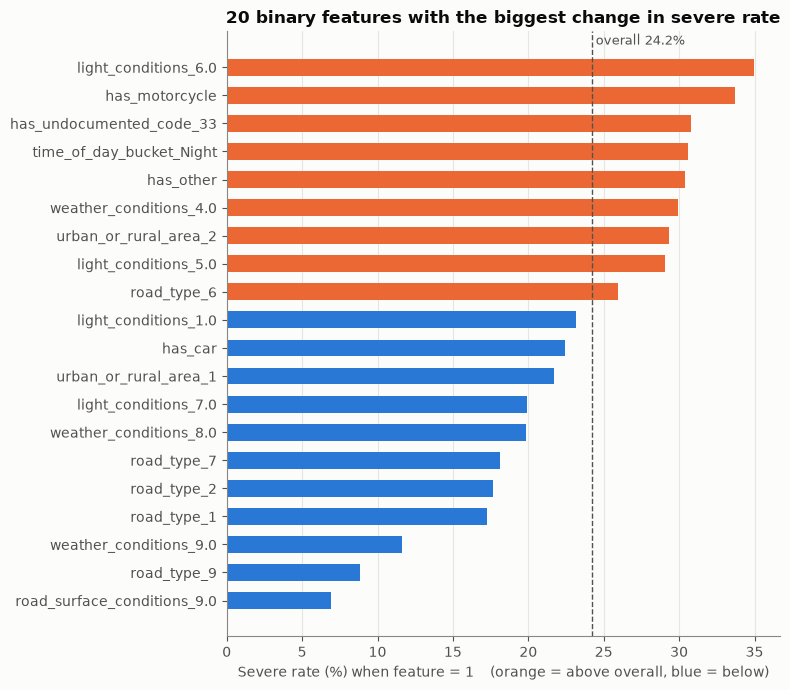

In [12]:
top_bin = bin_df.sort_values("abs_diff", ascending=False).head(20).sort_values("severe_%_when_1")
colors = [ORANGE if l > 1 else BLUE for l in top_bin["lift"]]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_bin["feature"], top_bin["severe_%_when_1"], color=colors, height=0.6)
ax.axvline(overall_severe, color=INK2, linestyle="--", linewidth=1)
ax.text(overall_severe, len(top_bin) - 0.3, f" overall {overall_severe:.1f}%", color=INK2, fontsize=9, va="bottom")
ax.set_xlabel("Severe rate (%) when feature = 1    (orange = above overall, blue = below)")
ax.set_title("20 binary features with the biggest change in severe rate")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 7. Mutual information — one score for every feature
Mutual information measures how much knowing a feature reduces uncertainty about severity. It works for both discrete and continuous features and catches non-linear relationships, so it is the main **common scale** for ranking. It is estimated on a stratified sample of 100,000 rows to keep run time reasonable.

In [13]:
sample_size = min(100_000, len(X))
if sample_size < len(X):
    X_s, _, y_s, _ = train_test_split(X, y, train_size=sample_size, stratify=y, random_state=42)
else:
    X_s, y_s = X, y

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    mi = mutual_info_classif(
        X_s, y_s,
        discrete_features=np.array([c in discrete for c in X.columns]),
        random_state=42,
    )
mi_df = (pd.DataFrame({"feature": X.columns, "mutual_info": mi})
         .sort_values("mutual_info", ascending=False)
         .reset_index(drop=True))
mi_df.head(30).round(5)

,feature,mutual_info
0,number_of_vehicles,0.01264
1,latitude,0.01187
2,longitude,0.00783
3,speed_limit,0.00730
4,has_car,0.00477
5,urban_or_rural_area_2,0.00468
6,urban_or_rural_area_1,0.00467
7,max_driver_age,0.00440
8,has_motorcycle,0.00438
9,avg_driver_age,0.00368


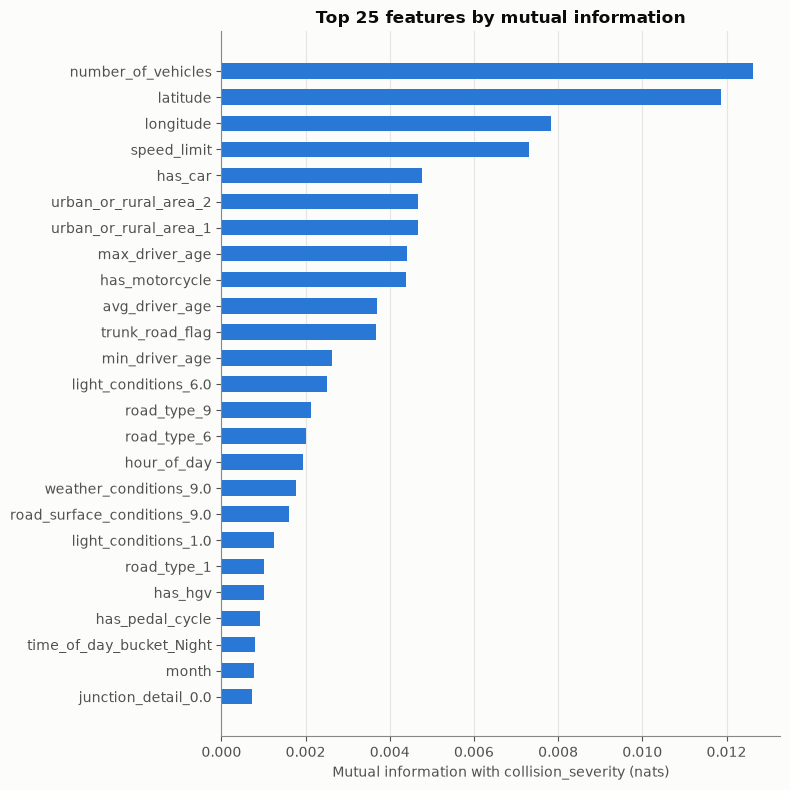

In [14]:
top_mi = mi_df.head(25).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top_mi["feature"], top_mi["mutual_info"], color=BLUE, height=0.6)
ax.set_xlabel("Mutual information with collision_severity (nats)")
ax.set_title("Top 25 features by mutual information")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 8. Combined summary — one row per feature

In [15]:
effect = pd.concat([
    chi_df[["feature", "cramers_v", "strength"]].rename(columns={"cramers_v": "effect_size"}).assign(test="Cramér's V"),
    cont_df[["feature", "epsilon_sq", "strength"]].rename(columns={"epsilon_sq": "effect_size"}).assign(test="Epsilon²"),
])

summary = (mi_df
           .merge(effect, on="feature", how="left")
           .merge(bin_df[["feature", "severe_%_when_1", "lift"]], on="feature", how="left")
           .merge(cont_df[["feature", "spearman_rho"]], on="feature", how="left"))
summary.insert(0, "mi_rank", range(1, len(summary) + 1))
summary = summary[["mi_rank", "feature", "mutual_info", "test", "effect_size", "strength",
                   "spearman_rho", "severe_%_when_1", "lift"]]
summary.round(4)

,mi_rank,feature,mutual_info,test,effect_size,strength,spearman_rho,severe_%_when_1,lift
0,1,number_of_vehicles,0.0126,Epsilon²,0.0088,negligible,-0.0936,NaN,NaN
1,2,latitude,0.0119,Epsilon²,0.0066,negligible,0.0804,NaN,NaN
2,3,longitude,0.0078,Epsilon²,0.0050,negligible,-0.0688,NaN,NaN
3,4,speed_limit,0.0073,Cramér's V,0.0910,weak,NaN,NaN,NaN
4,5,has_car,0.0048,Cramér's V,0.1048,weak,NaN,22.4212,0.9263
5,6,urban_or_rural_area_2,0.0047,Cramér's V,0.1044,weak,NaN,29.3375,1.2120
6,7,urban_or_rural_area_1,0.0047,Cramér's V,0.1044,weak,NaN,21.6973,0.8964
7,8,max_driver_age,0.0044,Epsilon²,0.0021,negligible,0.0436,NaN,NaN
8,9,has_motorcycle,0.0044,Cramér's V,0.0989,negligible,NaN,33.7206,1.3931
9,10,avg_driver_age,0.0037,Epsilon²,0.0021,negligible,0.0431,NaN,NaN


In [16]:
strong_or_moderate = summary[summary["strength"].isin(["moderate", "strong"])]["feature"].tolist()
weak = summary[summary["strength"] == "weak"]["feature"].tolist()
negligible = summary[summary["strength"] == "negligible"]["feature"].tolist()

print("=" * 80)
print("FEATURE ↔ COLLISION SEVERITY: KEY FINDINGS")
print("=" * 80)
print(f"\nTop 10 by mutual information:")
for _, r in summary.head(10).iterrows():
    print(f"  {r['mi_rank']:>2}. {r['feature']:<35} MI={r['mutual_info']:.5f}  ({r['test']}={r['effect_size']:.4f}, {r['strength']})")

print(f"\nModerate/strong effect ({len(strong_or_moderate)}): {strong_or_moderate or 'none'}")
print(f"\nWeak effect ({len(weak)}): {weak or 'none'}")
print(f"\nNegligible effect ({len(negligible)}): {len(negligible)} features")

print(f"\nStrongest original categorical variable: {group_df.iloc[0]['variable']} (Cramér's V = {group_df.iloc[0]['cramers_v']:.4f})")

risk_up = bin_df[bin_df["lift"] > 1].head(5)
print("\nConditions most linked to MORE severe outcomes (highest lift):")
for _, r in risk_up.iterrows():
    print(f"  {r['feature']:<35} severe {r['severe_%_when_1']:.1f}% vs overall {overall_severe:.1f}%  (lift {r['lift']:.2f})")

FEATURE ↔ COLLISION SEVERITY: KEY FINDINGS

Top 10 by mutual information:
   1. number_of_vehicles                  MI=0.01264  (Epsilon²=0.0088, negligible)
   2. latitude                            MI=0.01187  (Epsilon²=0.0066, negligible)
   3. longitude                           MI=0.00783  (Epsilon²=0.0050, negligible)
   4. speed_limit                         MI=0.00730  (Cramér's V=0.0910, weak)
   5. has_car                             MI=0.00477  (Cramér's V=0.1048, weak)
   6. urban_or_rural_area_2               MI=0.00468  (Cramér's V=0.1044, weak)
   7. urban_or_rural_area_1               MI=0.00467  (Cramér's V=0.1044, weak)
   8. max_driver_age                      MI=0.00440  (Epsilon²=0.0021, negligible)
   9. has_motorcycle                      MI=0.00438  (Cramér's V=0.0989, negligible)
  10. avg_driver_age                      MI=0.00368  (Epsilon²=0.0021, negligible)

Moderate/strong effect (0): none

Weak effect (4): ['speed_limit', 'has_car', 'urban_or_rural_area_

## 9. How to read these results
1. **Significance ≠ importance.** With ~400k rows nearly every p-value is ≈ 0. Judge features by effect size (Cramér's V, epsilon²) and mutual information.
2. **Weak individual associations are normal for severity prediction.** Severity depends on many interacting factors; a model can combine several weak signals into a useful prediction. Low scores here don't automatically mean "drop the feature".
3. **Read one-hot dummies together.** Use the grouped table in 4b to judge whole variables such as `light_conditions` rather than single dummies.
4. **Association ≠ causation.** For example, rural roads may look riskier partly because they have higher speed limits.
5. **Cyclic features.** `month` and `hour_of_day` were scaled linearly in notebook 12, so December and January sit far apart. Sin/cos encoding may reveal a clearer relationship.
6. **Class imbalance.** Fatal collisions are only ~1.5% of rows. Lift and fatal % columns help show signals that overall accuracy would hide.

**Next step:** use these rankings to guide feature selection and to sanity-check model feature importances in the classification notebook.